In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

df = pd.read_csv("product_review_sentiment_dataset.csv")
df

,review,label
0,"Great quality router, would definitely buy again.",1
1,The headphones is poorly made and feels cheap.,0
2,I am impressed with how well this watch performs.,1
3,"Terrible phone, complete waste of money.",0
4,"The phone is okay, does the job most of the time.",1
...,...,...
1395,"Best headphones I have ever purchased, super h...",1
1396,"Bad quality keyboard, would not recommend to a...",1
1397,"Very satisfied with this laptop, it is reliabl...",1
1398,The watch is poorly made and feels cheap.,0


In [2]:
df.shape

(1400, 2)

In [3]:
df.duplicated().sum()

np.int64(1049)

In [4]:
df.isnull().sum()

review    0
label     0
dtype: int64

In [5]:
df['label'].value_counts()

label
1    706
0    694
Name: count, dtype: int64

In [6]:
stop_words = stopwords.words("english")
ps = PorterStemmer()

In [7]:
def preprocessing(text):
    text = text.lower()
    token = nltk.word_tokenize(text)
    new = []
    for i in token:
        if i not in stop_words and i not in string.punctuation:
            stemmer = ps.stem(i)
            new.append(stemmer)
    return " ".join(new)

In [8]:
df["clean"] = df["review"].apply(preprocessing)
df.head()

,review,label,clean
0,"Great quality router, would definitely buy again.",1,great qualiti router would definit buy
1,The headphones is poorly made and feels cheap.,0,headphon poorli made feel cheap
2,I am impressed with how well this watch performs.,1,impress well watch perform
3,"Terrible phone, complete waste of money.",0,terribl phone complet wast money
4,"The phone is okay, does the job most of the time.",1,phone okay job time


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
vector = TfidfVectorizer()
X = vector.fit_transform(df["clean"])
y = df["label"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=55)

In [12]:
log = LogisticRegression()
log.fit(X_train,y_train)
print("LogisticRegression()")
print("train accuracy",log.score(X_train,y_train))
print("test accuracy",log.score(X_test,y_test))

LogisticRegression()
train accuracy 0.9387755102040817
test accuracy 0.9428571428571428


In [13]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=88)
dt.fit(X_train,y_train)
print("train accuracy",dt.score(X_train,y_train))
print("test accuracy",dt.score(X_test,y_test))

train accuracy 0.9408163265306122
test accuracy 0.930952380952381


In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test,log.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       203
           1       0.94      0.95      0.95       217

    accuracy                           0.94       420
   macro avg       0.94      0.94      0.94       420
weighted avg       0.94      0.94      0.94       420



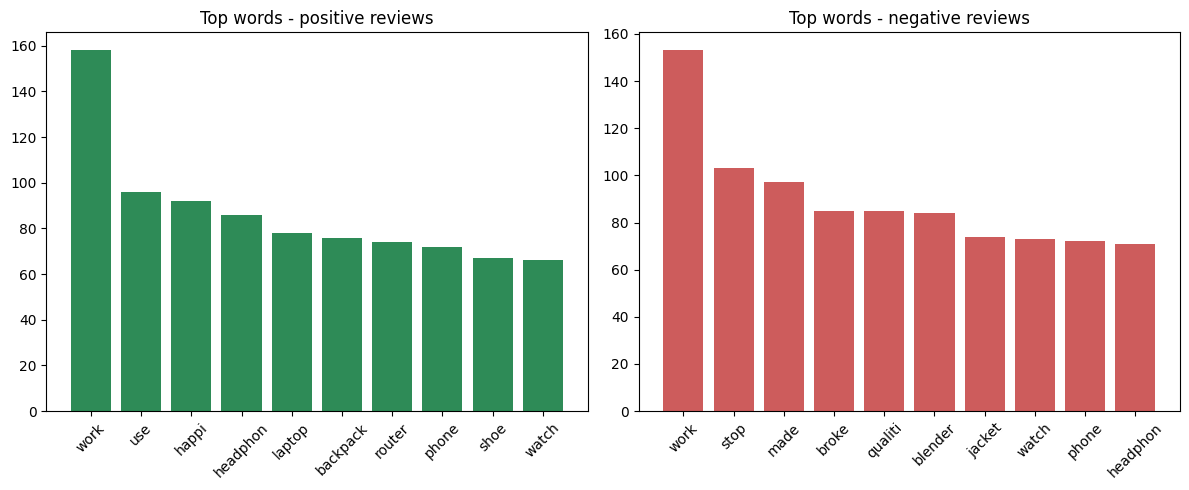

In [15]:
# most common words used in positive vs negative reviews
import matplotlib.pyplot as plt
from collections import Counter

pos_words = " ".join(df[df["label"]==1]["clean"]).split()
neg_words = " ".join(df[df["label"]==0]["clean"]).split()

pos_common = Counter(pos_words).most_common(10)
neg_common = Counter(neg_words).most_common(10)

fig,axes = plt.subplots(1,2,figsize=(12,5))
axes[0].bar(*zip(*pos_common),color="seagreen")
axes[0].set_title("Top words - positive reviews")
axes[0].tick_params(axis="x",rotation=45)
axes[1].bar(*zip(*neg_common),color="indianred")
axes[1].set_title("Top words - negative reviews")
axes[1].tick_params(axis="x",rotation=45)
plt.tight_layout()
plt.show()

In [16]:
def pred_text(text):
    text = text.lower()
    text = preprocessing(text)
    vec = vector.transform([text])
    predict = log.predict(vec)[0]
    if predict == 1:
        return "positive"
    else:
        return "negative"

In [17]:
print(pred_text("the laptop works great and I am very satisfied"))

positive


In [18]:
df[["review","label"]].sample(5)

,review,label
798,I am impressed with how well this phone performs.,1
1116,This laptop is the worst purchase I have made.,0
175,This jacket is the worst purchase I have made.,0
829,This jacket is the worst purchase I have made.,0
509,The keyboard works but the build quality could...,0
